<a href="https://colab.research.google.com/github/rizwanmohammed1500/Occupational-Stress-Analysis/blob/main/IndpProjV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analyzing Occupation and their Corresponding Stress Levels


Data Loaded!
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80     

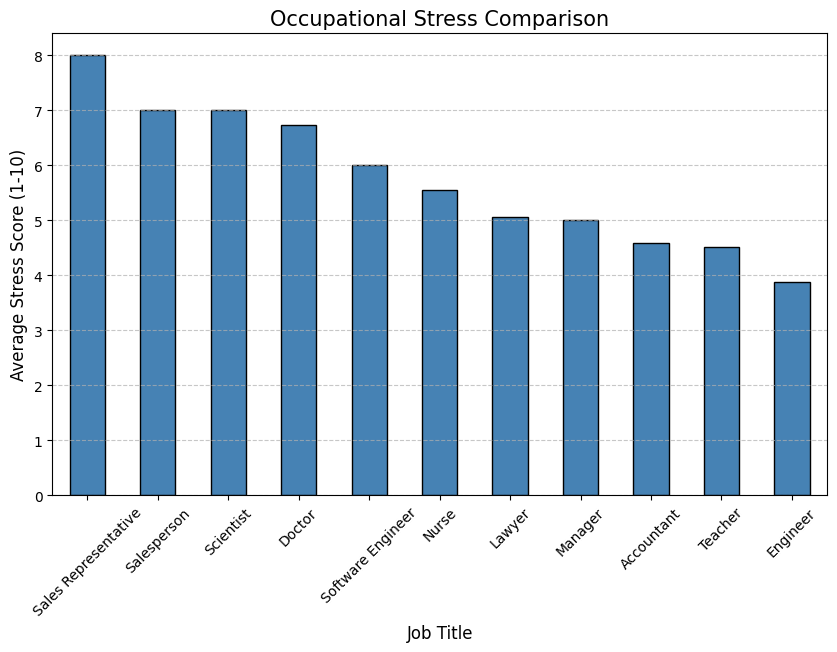

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('/content/Sleep_health_and_lifestyle_dataset.csv')
print("Data Loaded!")

print(df.head())
print("\nBMI Categories Found:")
print(df['BMI Category'].value_counts())

# Data Cleaning
print("\nMissing values per column:")
print(df.isnull().sum())


df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df_clean = df.drop(columns=['Blood Pressure', 'Person ID'])
print("Step 3: Data Cleaned and Structured!")
df_clean.head()

# Find average stress level per occupation
job_stats = df_clean.groupby('Occupation')['Stress Level'].mean().sort_values(ascending=False)
print("Average Stress Level by Job (1-10):")
print(job_stats)

# create the graph
plt.figure(figsize=(10, 6))
job_stats.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Occupational Stress Comparison', fontsize=15)
plt.ylabel('Average Stress Score (1-10)', fontsize=12)
plt.xlabel('Job Title', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [17]:
print(df_clean['Occupation'].value_counts())

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Scientist                4
Software Engineer        4
Sales Representative     2
Manager                  1
Name: count, dtype: int64
